# Experiment: MOSTA LR Interaction Timecourse Review

Goal:
- Start directly from the dense interpolation pipeline.
- Compute the full interpolated LR panel on the communication-supported grid `0, 0.5, 1, 1.5, 2, 2.5, 3`.
- Inspect all LR pairs by curve pattern, not only one hand-picked pair.

Default reading order:
1. Run or reuse the dense interpolation + projection outputs.
2. Build a long table for every `lr_pair x time`.
3. View the panel through several figure styles:
   - pattern-grouped heatmap
   - normalized curve small multiples
   - cluster prototype panel
   - optional single-pair cell-type drill-down


## Logic

This notebook reuses the existing production implementation:

1. `mosta_interp_sde_to_gene_local.py`
   - split-SDE simulation from `t=0` to the requested time grid
   - classifier-based annotation transfer
   - PCA backprojection into gene space
   - output in count space for LR projection
2. `mosta_lr_projection_local.py`
   - use the communication matrix at each timepoint
   - compute `LR(A->B) = mean_expr_A(ligand) * mean_expr_B(receptor) * communication(A->B)`
3. Notebook summarization
   - one scalar per LR pair per timepoint: `global_score = matrix.sum()`
   - one optional cell-type decomposition per LR pair: incoming / outgoing / total by tissue class

Important interpretation:
- The score is only truly computed at the communication-supported grid.
- The smooth curves below are display helpers, not extra simulated communication timepoints.

Switches:
- `RUN_DENSE_PIPELINE` decides whether to execute the heavy interpolation/projection commands.
- `USE_PIECEWISE_WARP` decides whether interpolation uses the piecewise warp path.
- So `RUN_DENSE_PIPELINE = True` plus `USE_PIECEWISE_WARP = True` means: run the dense pipeline with piecewise warp enabled.


In [1]:
from __future__ import annotations

import json
import math
import pickle
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from scipy.interpolate import PchipInterpolator
except Exception:
    PchipInterpolator = None

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "font.size": 11,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    markers = [
        "evaluation/mosta/code/mosta_lr_projection_local.py",
        "results/mosta_interp_0_3_0208_n_pc_12/mosta_all_time_communications.pkl",
    ]
    for candidate in candidates:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(
        "Could not locate the repo root from the current notebook working directory. "
        "Please open the notebook inside the CytoBridge-ST-1104 workspace."
    )


def time_key(t: float) -> str:
    return str(float(t))


def time_token(t: float) -> str:
    return f"{float(t):.3f}".replace(".", "p").replace("-", "n")


PROJECT_ROOT = find_project_root()
print("PROJECT_ROOT:", PROJECT_ROOT)

COMM_PKL = PROJECT_ROOT / "results/mosta_interp_0_3_0208_n_pc_12/mosta_all_time_communications.pkl"
INTERP_SCRIPT = PROJECT_ROOT / "evaluation/mosta/code/mosta_interp_sde_to_gene_local.py"
PROJECTION_SCRIPT = PROJECT_ROOT / "evaluation/mosta/code/mosta_lr_projection_local.py"

DENSE_TIMES = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
RUN_DENSE_PIPELINE = True
USE_PIECEWISE_WARP = False
N_SAMPLES = 5000
RUN_TAG_SUFFIX = "_pca_mean"
ALLOW_SCORE_FALLBACK = False
FORCE_REBUILD_INTERP = True
CONDA_ENV = "DeepRUOTv2"

LR_PAIR = "Wnt3a_Fzd7_Lrp6"
N_CLUSTERS = 2
TOP_N_HEATMAP = 31
TOP_N_SMALL_MULTIPLES = 31
TOP_N_RANK = 8

PCA_MEAN_CSV = PROJECT_ROOT / "mosta_pca_mean.csv"
if not PCA_MEAN_CSV.exists():
    raise FileNotFoundError(f"Missing PCA mean file: {PCA_MEAN_CSV}")

CLASSIFIER_CACHE_DIR = PROJECT_ROOT / "results/mosta_interp_0_3_0208_n_pc_12" / "classifier_cache"
if not CLASSIFIER_CACHE_DIR.exists():
    CLASSIFIER_CACHE_DIR = PROJECT_ROOT / "results/mosta_interp_0_3_0208_n_pc_12"

run_tag = f"dense_n{N_SAMPLES}" + ("_piecewise" if USE_PIECEWISE_WARP else "_plain") + RUN_TAG_SUFFIX
DENSE_BASE_OUT = PROJECT_ROOT / f"results/mosta_lr_timecourse_{run_tag}"
DENSE_H5AD_ROOT = DENSE_BASE_OUT / "interp_h5ad_dense"
DENSE_INTERP_MAP_JSON = DENSE_H5AD_ROOT / "interp_map.json"
DENSE_SCORE_DIR = DENSE_BASE_OUT / "interp_projection_dense"

FIG_DIR = PROJECT_ROOT / "output/jupyter-notebook/figures/mosta-lr-interaction-timecourse-review"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def count_score_pickles(score_dir: Path) -> int:
    if not score_dir.exists():
        return 0
    return len(list(score_dir.glob("lr_scores_*.pkl")))


def resolve_read_score_dir(primary_score_dir: Path) -> Path:
    primary_count = count_score_pickles(primary_score_dir)
    if primary_count > 0:
        print(f"using score dir: {primary_score_dir} ({primary_count} files)")
        return primary_score_dir

    if not ALLOW_SCORE_FALLBACK:
        print(f"primary score dir is empty and fallback is disabled: {primary_score_dir}")
        return primary_score_dir

    candidates = []
    for candidate in sorted(PROJECT_ROOT.glob("results/mosta_lr_timecourse*/interp_projection_dense")):
        n_files = count_score_pickles(candidate)
        if n_files > 0:
            candidates.append((candidate, n_files))

    if candidates:
        chosen, n_files = candidates[-1]
        print(f"primary score dir is empty: {primary_score_dir}")
        print(f"falling back to existing score dir: {chosen} ({n_files} files)")
        return chosen

    print(f"no readable dense score dir found yet. expected primary: {primary_score_dir}")
    return primary_score_dir


with COMM_PKL.open("rb") as f:
    comm_all = pickle.load(f)
COMMUNICATION_TIMES = sorted(float(k) for k in comm_all.keys())
print("communication-supported grid:", COMMUNICATION_TIMES)
assert set(DENSE_TIMES).issubset(set(COMMUNICATION_TIMES))


PROJECT_ROOT: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104
communication-supported grid: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]


In [3]:
PALETTE = {
    "ink": "#17324D",
    "steel": "#5F7485",
    "sand": "#D7C3A3",
    "rust": "#B85C38",
    "sage": "#73937E",
    "grid": "#D8DEE3",
}


def dense_h5ad_path(t: float) -> Path:
    token = time_token(t)
    return DENSE_H5AD_ROOT / f"t{token}" / f"adata_t{token}_with_genes.h5ad"


def score_path(score_dir: Path, t: float) -> Path:
    return score_dir / f"lr_scores_{time_key(t)}.pkl"


def run_cmd(cmd, execute: bool = False):
    cmd = [str(x) for x in cmd]
    print("$", " ".join(cmd))
    if execute:
        subprocess.run(cmd, check=True)


def build_interp_cmd(target_times: list[float]):
    if not target_times:
        raise ValueError("target_times must be non-empty")
    cmd = [
        "conda",
        "run",
        "-n",
        CONDA_ENV,
        "python",
        INTERP_SCRIPT,
        "--data-csv",
        PROJECT_ROOT / "evaluation/mosta/data/mosta_four_time_with_celltype_refined.csv",
        "--annotation-col",
        "Annotation",
        "--pca-components-csv",
        PROJECT_ROOT / "mosta_pca_components_with_gene_names.csv",
        "--pca-mean-file",
        PCA_MEAN_CSV,
        "--export-all-times",
        "--target-time",
        time_key(target_times[0]),
        "--ts-points",
        ",".join(time_key(t) for t in target_times),
        "--start-time",
        "0.0",
        "--n-samples",
        str(N_SAMPLES),
        "--classifier-n-pcs",
        "12",
        "--classifier-best-metric",
        "bacc",
        "--classifier-cache-dir",
        CLASSIFIER_CACHE_DIR,
        "--classifier-train-on-full-data",
        "--output-x-space",
        "count",
        "--count-transform",
        "clip",
        "--output-dir",
        DENSE_H5AD_ROOT,
    ]
    if USE_PIECEWISE_WARP:
        cmd.append("--spatial-warp-to-observed-piecewise")
    return cmd


def build_projection_cmd(target_times: list[float]):
    return [
        "conda",
        "run",
        "-n",
        CONDA_ENV,
        "python",
        PROJECTION_SCRIPT,
        "--communications-pkl",
        COMM_PKL,
        "--interp-map-json",
        DENSE_INTERP_MAP_JSON,
        "--lr-db",
        PROJECT_ROOT / "database/CellChatDB.ligrec.mouse.csv",
        "--real-h5ad",
        PROJECT_ROOT / "spatial_data/Mouse_embryo_all_stage.h5ad",
        "--annotation-col",
        "Annotation",
        "--time-keys",
        ",".join(time_key(t) for t in target_times),
        "--x-space",
        "count",
        "--save-key-mode",
        "comm",
        "--output-dir",
        DENSE_SCORE_DIR,
    ]


def prepare_dense_timecourse(target_times: list[float], execute: bool = False):
    DENSE_H5AD_ROOT.mkdir(parents=True, exist_ok=True)
    DENSE_SCORE_DIR.mkdir(parents=True, exist_ok=True)

    interp_map = {time_key(t): str(dense_h5ad_path(t)) for t in target_times}
    missing_times = []
    for t in target_times:
        h5ad_path = dense_h5ad_path(t)
        if h5ad_path.exists() and not FORCE_REBUILD_INTERP:
            print(f"[interp exists] t={t}: {h5ad_path}")
        else:
            missing_times.append(t)

    if missing_times or FORCE_REBUILD_INTERP:
        print("running one shared split-SDE simulation for times:", target_times)
        run_cmd(build_interp_cmd(target_times), execute=execute)
    else:
        print("all interpolated gene-space h5ad files already exist")

    DENSE_INTERP_MAP_JSON.write_text(json.dumps(interp_map, indent=2), encoding="utf-8")
    print("wrote:", DENSE_INTERP_MAP_JSON)
    run_cmd(build_projection_cmd(target_times), execute=execute)
    return DENSE_INTERP_MAP_JSON, DENSE_SCORE_DIR


In [4]:
def load_score_record(path: Path) -> dict:
    with path.open("rb") as f:
        return pickle.load(f)


def collect_all_lr_timecourses(score_dir: Path, times: list[float]) -> tuple[pd.DataFrame, pd.DataFrame]:
    pair_rows = []
    type_rows = []
    missing = []

    score_dir = resolve_read_score_dir(score_dir)
    print("collecting LR timecourses from:", score_dir)

    for t in times:
        path = score_path(score_dir, t)
        if not path.exists():
            missing.append(path.name)
            continue

        record = load_score_record(path)
        cell_types = [str(x) for x in np.asarray(record["cell_types"]).tolist()]
        for lr_pair, mat_raw in record["lr_scores"].items():
            mat = np.asarray(mat_raw, dtype=float)
            incoming = mat.sum(axis=0)
            outgoing = mat.sum(axis=1)
            total = incoming + outgoing

            pair_rows.append(
                {
                    "time": float(record["comm_time_key"]),
                    "lr_pair": str(lr_pair),
                    "global_score": float(mat.sum()),
                    "max_edge": float(mat.max()),
                    "nonzero_edges": int((mat > 0).sum()),
                    "n_cell_types": int(len(cell_types)),
                    "peak_receiver": cell_types[int(np.argmax(incoming))],
                    "peak_sender": cell_types[int(np.argmax(outgoing))],
                }
            )

            type_rows.extend(
                {
                    "time": float(record["comm_time_key"]),
                    "lr_pair": str(lr_pair),
                    "cell_type": cell_type,
                    "incoming": float(in_v),
                    "outgoing": float(out_v),
                    "total": float(tot_v),
                }
                for cell_type, in_v, out_v, tot_v in zip(cell_types, incoming, outgoing, total)
            )

    pair_cols = ["time", "lr_pair", "global_score", "max_edge", "nonzero_edges", "n_cell_types", "peak_receiver", "peak_sender"]
    type_cols = ["time", "lr_pair", "cell_type", "incoming", "outgoing", "total"]

    if pair_rows:
        pair_df = pd.DataFrame(pair_rows).sort_values(["lr_pair", "time"]).reset_index(drop=True)
    else:
        pair_df = pd.DataFrame(columns=pair_cols)

    if type_rows:
        type_df = pd.DataFrame(type_rows).sort_values(["lr_pair", "time", "total"], ascending=[True, True, False]).reset_index(drop=True)
    else:
        type_df = pd.DataFrame(columns=type_cols)

    if missing:
        print("missing score files:", missing)
    return pair_df, type_df


def make_display_curve(x, y, n_points: int = 300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size <= 1:
        return x, y
    x_dense = np.linspace(x.min(), x.max(), n_points)
    if PchipInterpolator is not None and x.size >= 3:
        y_dense = PchipInterpolator(x, y)(x_dense)
    else:
        y_dense = np.interp(x_dense, x, y)
    return x_dense, y_dense


def rowwise_minmax(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float)
    lo = matrix.min(axis=1, keepdims=True)
    hi = matrix.max(axis=1, keepdims=True)
    return np.divide(matrix - lo, np.maximum(hi - lo, 1e-12))


def build_pair_pivot(pair_df: pd.DataFrame, value_col: str = "global_score") -> pd.DataFrame:
    return pair_df.pivot(index="lr_pair", columns="time", values=value_col).sort_index(axis=1)


def infer_shape_clusters(pair_df: pd.DataFrame, pattern_df: pd.DataFrame, n_clusters: int = 4) -> pd.DataFrame:
    if pattern_df.empty:
        return pattern_df.copy()

    pivot = build_pair_pivot(pair_df[pair_df["lr_pair"].isin(pattern_df["lr_pair"])])
    pivot = pivot.loc[pattern_df["lr_pair"]]
    norm = pd.DataFrame(rowwise_minmax(pivot.to_numpy(dtype=float)), index=pivot.index, columns=pivot.columns)

    cluster_map = {}
    ordered_pairs = list(norm.index)
    try:
        from scipy.cluster.hierarchy import fcluster, leaves_list, linkage

        if norm.shape[0] >= 2:
            linkage_matrix = linkage(norm.to_numpy(dtype=float), method="ward", metric="euclidean")
            ordered_pairs = norm.index[leaves_list(linkage_matrix)].tolist()
            n_eff = min(max(2, int(n_clusters)), norm.shape[0])
            raw_clusters = fcluster(linkage_matrix, t=n_eff, criterion="maxclust")
            raw_map = dict(zip(norm.index.tolist(), raw_clusters.tolist()))

            remap = {}
            next_id = 1
            for lr_pair in ordered_pairs:
                raw_id = raw_map[lr_pair]
                if raw_id not in remap:
                    remap[raw_id] = next_id
                    next_id += 1
                cluster_map[lr_pair] = remap[raw_id]
        else:
            cluster_map = {ordered_pairs[0]: 1}
    except Exception:
        fallback_order = pattern_df.sort_values(["peak_time", "delta_end_start", "auc"], ascending=[True, False, False])["lr_pair"].tolist()
        ordered_pairs = fallback_order
        for lr_pair in ordered_pairs:
            peak_time = float(pattern_df.loc[pattern_df["lr_pair"] == lr_pair, "peak_time"].iloc[0])
            if peak_time <= 1.0:
                cluster_map[lr_pair] = 1
            elif peak_time <= 2.0:
                cluster_map[lr_pair] = 2
            elif peak_time < 3.0:
                cluster_map[lr_pair] = 3
            else:
                cluster_map[lr_pair] = 4

    shape_rank = {lr_pair: i for i, lr_pair in enumerate(ordered_pairs)}
    out = pattern_df.copy()
    out["cluster_id"] = out["lr_pair"].map(lambda x: int(cluster_map.get(x, 1)))
    out["shape_rank"] = out["lr_pair"].map(lambda x: int(shape_rank.get(x, 10**9)))
    return out.sort_values(["cluster_id", "shape_rank", "auc"], ascending=[True, True, False]).reset_index(drop=True)


def summarize_lr_patterns(pair_df: pd.DataFrame, n_clusters: int = 4) -> pd.DataFrame:
    if pair_df.empty:
        return pd.DataFrame()

    rows = []
    for lr_pair, sub in pair_df.groupby("lr_pair", sort=False):
        sub = sub.sort_values("time")
        times = sub["time"].to_numpy(dtype=float)
        scores = sub["global_score"].to_numpy(dtype=float)
        start = float(scores[0])
        end = float(scores[-1])
        peak_idx = int(np.argmax(scores))
        trough_idx = int(np.argmin(scores))
        rows.append(
            {
                "lr_pair": lr_pair,
                "auc": float(np.trapz(scores, times)),
                "peak_time": float(times[peak_idx]),
                "peak_score": float(scores[peak_idx]),
                "trough_time": float(times[trough_idx]),
                "start_score": start,
                "end_score": end,
                "delta_end_start": float(end - start),
                "fold_end_start": float(end / max(start, 1e-12)),
                "score_range": float(scores.max() - scores.min()),
            }
        )

    pattern_df = pd.DataFrame(rows)
    return infer_shape_clusters(pair_df=pair_df, pattern_df=pattern_df, n_clusters=n_clusters)


def ordered_pairs(pattern_df: pd.DataFrame, top_n: int | None = None, order_by: str = "shape") -> list[str]:
    if pattern_df.empty:
        return []
    if order_by == "shape" and {"cluster_id", "shape_rank"}.issubset(pattern_df.columns):
        order = (
            pattern_df.sort_values(["cluster_id", "shape_rank", "auc"], ascending=[True, True, False])["lr_pair"].tolist()
        )
    else:
        order = pattern_df.sort_values([order_by, "peak_score"], ascending=[False, False])["lr_pair"].tolist()
    return order if top_n is None else order[:top_n]


def style_ax(ax, ylabel: str):
    ax.set_xlabel("Simulated time")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", color=PALETTE["grid"], linewidth=0.8)
    ax.spines["left"].set_color("#8796A3")
    ax.spines["bottom"].set_color("#8796A3")


def cluster_palette():
    return {
        1: "#D97757",
        2: "#2A7F9E",
        3: "#6A994E",
        4: "#7B6D8D",
        5: "#C2A83E",
        6: "#4D908E",
    }


def cluster_representatives(pair_df: pd.DataFrame, pattern_df: pd.DataFrame, cluster_id: int, top_k: int = 3) -> list[str]:
    members = pattern_df[pattern_df["cluster_id"] == cluster_id]["lr_pair"].tolist()
    if not members:
        return []
    pivot = build_pair_pivot(pair_df[pair_df["lr_pair"].isin(members)]).loc[members]
    norm = rowwise_minmax(pivot.to_numpy(dtype=float))
    centroid = norm.mean(axis=0, keepdims=True)
    dist = ((norm - centroid) ** 2).sum(axis=1)
    order = np.argsort(dist)
    return [members[i] for i in order[: min(top_k, len(members))]]


def plot_lr_heatmap(pair_df: pd.DataFrame, pattern_df: pd.DataFrame, top_n: int = 31, normalize_rows: bool = True, out_name: str | None = None):
    from matplotlib.colors import LinearSegmentedColormap, ListedColormap

    pairs = ordered_pairs(pattern_df, top_n=top_n, order_by="shape")
    pivot = build_pair_pivot(pair_df[pair_df["lr_pair"].isin(pairs)]).loc[pairs]
    matrix = pivot.to_numpy(dtype=float)
    if normalize_rows:
        matrix = rowwise_minmax(matrix)

    cluster_series = pattern_df.set_index("lr_pair").loc[pairs, "cluster_id"].astype(int)
    cluster_ids = sorted(cluster_series.unique().tolist())
    cpal = cluster_palette()
    strip_colors = [cpal.get(cid, "#999999") for cid in cluster_ids]

    heat_cmap = LinearSegmentedColormap.from_list(
        "lr_shape_heat",
        ["#F7F3EB", "#DCEAE6", "#93B7BE", "#2D5D6F", "#142B3A"],
    )

    fig_h = max(4.8, 0.24 * len(pairs))
    fig = plt.figure(figsize=(8.6, fig_h), dpi=240, facecolor="white")
    gs = fig.add_gridspec(1, 2, width_ratios=[0.14, 1.0], wspace=0.04)
    ax_strip = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[0, 1])

    strip_matrix = np.array([[cluster_ids.index(cid)] for cid in cluster_series.to_numpy()])
    ax_strip.imshow(strip_matrix, aspect="auto", cmap=ListedColormap(strip_colors), interpolation="nearest")
    ax_strip.set_title("Pattern", fontsize=9, pad=8)
    ax_strip.set_xticks([])
    ax_strip.set_yticks([])
    for spine in ax_strip.spines.values():
        spine.set_visible(False)

    im = ax.imshow(matrix, aspect="auto", cmap=heat_cmap, interpolation="nearest")
    ax.set_title("Pattern-grouped LR trajectories", loc="left", pad=10)
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels([str(c) for c in pivot.columns])
    ax.set_xlabel("Simulated time")
    ax.set_ylabel("Pattern")

    centers = []
    labels = []
    start = 0
    prev_cluster = int(cluster_series.iloc[0])
    for idx, cid in enumerate(cluster_series.iloc[1:], start=1):
        cid = int(cid)
        if cid != prev_cluster:
            ax.axhline(idx - 0.5, color="white", linewidth=2.2)
            ax_strip.axhline(idx - 0.5, color="white", linewidth=2.2)
            centers.append((start + idx - 1) / 2.0)
            labels.append(f"Pattern {prev_cluster}")
            start = idx
        prev_cluster = cid
    centers.append((start + len(cluster_series) - 1) / 2.0)
    labels.append(f"Pattern {prev_cluster}")

    ax.set_yticks(centers)
    ax.set_yticklabels(labels, fontsize=10)

    cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cb.outline.set_visible(False)
    cb.ax.set_ylabel("Row-normalized score" if normalize_rows else "Raw score", rotation=90)
    fig.tight_layout()
    if out_name is not None:
        out_path = FIG_DIR / out_name
        fig.savefig(out_path, bbox_inches="tight")
        print("saved:", out_path)
    return fig, (ax_strip, ax)


def plot_lr_small_multiples(pair_df: pd.DataFrame, pattern_df: pd.DataFrame, top_n: int = 12, normalize: bool = True, out_name: str | None = None):
    pairs = ordered_pairs(pattern_df, top_n=top_n, order_by="shape")
    pmeta = pattern_df.set_index("lr_pair")
    cpal = cluster_palette()

    ncols = 4
    nrows = math.ceil(len(pairs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(13.6, 2.9 * nrows), dpi=240, squeeze=False, facecolor="white")
    axes = axes.ravel()

    for ax, lr_pair in zip(axes, pairs):
        sub = pair_df[pair_df["lr_pair"] == lr_pair].sort_values("time")
        x = sub["time"].to_numpy(dtype=float)
        y = sub["global_score"].to_numpy(dtype=float)
        y_plot = (y - y.min()) / max(y.max() - y.min(), 1e-12) if normalize else y
        x_dense, y_dense = make_display_curve(x, y_plot)

        cluster_id = int(pmeta.loc[lr_pair, "cluster_id"]) if "cluster_id" in pmeta.columns else 1
        color = cpal.get(cluster_id, PALETTE["ink"])

        ax.plot(x_dense, y_dense, color=color, linewidth=2.2)
        ax.scatter(x, y_plot, s=18, color=color, edgecolor="white", linewidth=0.6, zorder=3)
        ax.set_title(f"Pattern {cluster_id}  {lr_pair}", loc="left", fontsize=9, pad=4, color=color)
        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(-0.03, 1.03 if normalize else max(float(y_plot.max()) * 1.05, 1e-12))
        ax.grid(axis="y", color=PALETTE["grid"], linewidth=0.6)
        ax.tick_params(labelsize=8)
        ax.set_xlabel("time", fontsize=8)
        ax.set_ylabel("norm score" if normalize else "score", fontsize=8)
        ax.set_facecolor("#FBFAF8")
        for side in ("left", "bottom"):
            ax.spines[side].set_color(color)
            ax.spines[side].set_linewidth(1.2)

    for ax in axes[len(pairs):]:
        ax.axis("off")

    fig.suptitle("Shape-clustered LR curve panel", x=0.01, ha="left", y=1.01, fontsize=13)
    fig.tight_layout()
    if out_name is not None:
        out_path = FIG_DIR / out_name
        fig.savefig(out_path, bbox_inches="tight")
        print("saved:", out_path)
    return fig, axes


def plot_cluster_prototypes(pair_df: pd.DataFrame, pattern_df: pd.DataFrame, out_name: str | None = None):
    if pattern_df.empty:
        raise ValueError("pattern_df is empty")

    pivot = build_pair_pivot(pair_df[pair_df["lr_pair"].isin(pattern_df["lr_pair"])])
    all_pairs = pattern_df["lr_pair"].tolist()
    pivot = pivot.loc[all_pairs]
    norm = pd.DataFrame(rowwise_minmax(pivot.to_numpy(dtype=float)), index=pivot.index, columns=pivot.columns)
    pmeta = pattern_df.set_index("lr_pair")
    cluster_ids = sorted(pattern_df["cluster_id"].dropna().astype(int).unique().tolist())
    cpal = cluster_palette()

    fig, axes = plt.subplots(1, len(cluster_ids), figsize=(4.0 * len(cluster_ids), 4.2), dpi=240, squeeze=False, facecolor="white")
    axes = axes.ravel()

    for ax, cluster_id in zip(axes, cluster_ids):
        members = pmeta[pmeta["cluster_id"] == cluster_id].index.tolist()
        cluster_norm = norm.loc[members]
        x = cluster_norm.columns.to_numpy(dtype=float)
        mean_curve = cluster_norm.mean(axis=0).to_numpy(dtype=float)
        lo_curve = cluster_norm.quantile(0.2, axis=0).to_numpy(dtype=float)
        hi_curve = cluster_norm.quantile(0.8, axis=0).to_numpy(dtype=float)
        color = cpal.get(cluster_id, PALETTE["ink"])

        x_dense, mean_dense = make_display_curve(x, mean_curve)
        _, lo_dense = make_display_curve(x, lo_curve)
        _, hi_dense = make_display_curve(x, hi_curve)

        ax.fill_between(x_dense, lo_dense, hi_dense, color=color, alpha=0.18)
        ax.plot(x_dense, mean_dense, color=color, linewidth=2.8)
        ax.scatter(x, mean_curve, s=22, color=color, edgecolor="white", linewidth=0.6, zorder=3)
        ax.set_title(f"Pattern {cluster_id}", loc="left", color=color, pad=8)
        ax.set_ylim(-0.03, 1.03)
        style_ax(ax, ylabel="Normalized score")
        ax.set_facecolor("#FBFAF8")

    fig.suptitle("Cluster prototype panel", x=0.01, ha="left", y=1.02, fontsize=13)
    fig.tight_layout()
    if out_name is not None:
        out_path = FIG_DIR / out_name
        fig.savefig(out_path, bbox_inches="tight")
        print("saved:", out_path)
    return fig, axes


def plot_single_pair_drilldown(pair_df: pd.DataFrame, type_df: pd.DataFrame, lr_pair: str, top_n: int = 6, out_name: str | None = None):
    pair_sub = pair_df[pair_df["lr_pair"] == lr_pair].sort_values("time")
    if pair_sub.empty:
        raise KeyError(f"{lr_pair} not found in pair_df")

    ranked = (
        type_df[type_df["lr_pair"] == lr_pair]
        .groupby("cell_type")["total"]
        .max()
        .sort_values(ascending=False)
        .head(top_n)
        .index.tolist()
    )
    focus = type_df[(type_df["lr_pair"] == lr_pair) & (type_df["cell_type"].isin(ranked))].copy()

    fig, axes = plt.subplots(1, 3, figsize=(15.6, 4.1), dpi=220)

    x = pair_sub["time"].to_numpy(dtype=float)
    y = pair_sub["global_score"].to_numpy(dtype=float)
    y_norm = (y - y.min()) / max(y.max() - y.min(), 1e-12)

    x_dense, y_dense = make_display_curve(x, y)
    axes[0].plot(x_dense, y_dense, color=PALETTE["ink"], linewidth=2.5)
    axes[0].scatter(x, y, s=26, color=PALETTE["rust"], edgecolor="white", linewidth=0.7, zorder=3)
    axes[0].set_title(f"{lr_pair} global trajectory", loc="left", pad=10)
    style_ax(axes[0], ylabel="Global LR score")

    x_dense_norm, y_dense_norm = make_display_curve(x, y_norm)
    axes[1].plot(x_dense_norm, y_dense_norm, color=PALETTE["sage"], linewidth=2.5)
    axes[1].scatter(x, y_norm, s=26, color=PALETTE["sand"], edgecolor="white", linewidth=0.7, zorder=3)
    axes[1].set_title(f"{lr_pair} normalized trend", loc="left", pad=10)
    style_ax(axes[1], ylabel="Normalized score")
    axes[1].set_ylim(-0.03, 1.03)

    colors = ["#17324D", "#B85C38", "#73937E", "#5F7485", "#A25D5D", "#897B5F"]
    for color, cell_type in zip(colors, ranked):
        sub = focus[focus["cell_type"] == cell_type].sort_values("time")
        axes[2].plot(sub["time"], sub["total"], color=color, linewidth=2.0, label=cell_type)
        axes[2].scatter(sub["time"], sub["total"], s=18, color=color, edgecolor="white", linewidth=0.6, zorder=3)
    axes[2].set_title(f"{lr_pair} top cell-type contributions", loc="left", pad=10)
    style_ax(axes[2], ylabel="Cell-type total score")
    axes[2].legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left")

    fig.tight_layout()
    if out_name is not None:
        out_path = FIG_DIR / out_name
        fig.savefig(out_path, bbox_inches="tight")
        print("saved:", out_path)
    return fig, axes


## Run Dense Pipeline

This notebook now starts here conceptually.

Recommended usage:
- first run the next cell with `RUN_DENSE_PIPELINE = False` to see the exact commands and output paths;
- then set it to `True` when you want to execute the interpolation and LR projection;
- after that, the remaining analysis cells operate on the generated dense score files.


In [5]:
prepare_dense_timecourse(DENSE_TIMES, execute=RUN_DENSE_PIPELINE)


running one shared split-SDE simulation for times: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
$ conda run -n DeepRUOTv2 python /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/evaluation/mosta/code/mosta_interp_sde_to_gene_local.py --data-csv /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/evaluation/mosta/data/mosta_four_time_with_celltype_refined.csv --annotation-col Annotation --pca-components-csv /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/mosta_pca_components_with_gene_names.csv --pca-mean-file /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/mosta_pca_mean.csv --export-all-times --target-time 0.0 --ts-points 0.0,0.5,1.0,1.5,2.0,2.5,3.0 --start-time 0.0 --n-samples 5000 --classifier-n-pcs 12 --classifier-best-metric bacc --classifier-cache-dir /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/classifier_cache --classifier-train-on-full-data --output-x-space count --count-transform clip --output-dir /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_lr

... storing 'Annotation' as categorical
... storing 'timepoint' as categorical
... storing 'Annotation' as categorical
... storing 'timepoint' as categorical
... storing 'Annotation' as categorical
... storing 'timepoint' as categorical
... storing 'Annotation' as categorical
... storing 'timepoint' as categorical
... storing 'Annotation' as categorical
... storing 'timepoint' as categorical
... storing 'Annotation' as categorical
... storing 'timepoint' as categorical
... storing 'Annotation' as categorical
... storing 'timepoint' as categorical



Loaded communications: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/mosta_all_time_communications.pkl
  timepoints: ['0.0', '0.5', '1.0', '1.5', '2.0', '2.5', '3.0']
Loaded LR DB: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/database/CellChatDB.ligrec.mouse.csv
  unique pairs: 2017
Target timepoints: ['0.0', '0.5', '1.0', '1.5', '2.0', '2.5', '3.0']
Loaded real h5ad: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/spatial_data/Mouse_embryo_all_stage.h5ad
  resolved timepoint col: timepoint
  resolved annotation col: annotation

[comm_time=0.0 -> adata_time=0.0]
  source: interp h5ad (/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_lr_timecourse_dense_n5000_plain_pca_mean/interp_h5ad_dense/t0p000/adata_t0p000_with_genes.h5ad) | cells=5130
  saved: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_lr_timecourse_dense_n5000_plain_pca_mean/interp_projection_dense/lr_scores_0.0.pkl | pairs_scored= 31 | skipped_missing_genes= 1986



(PosixPath('/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_lr_timecourse_dense_n5000_plain_pca_mean/interp_h5ad_dense/interp_map.json'),
 PosixPath('/Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_lr_timecourse_dense_n5000_plain_pca_mean/interp_projection_dense'))

In [6]:
pair_df, type_df = collect_all_lr_timecourses(DENSE_SCORE_DIR, DENSE_TIMES)
pattern_df = summarize_lr_patterns(pair_df, n_clusters=N_CLUSTERS)

if pair_df.empty:
    print("dense score files are not ready yet. Set RUN_DENSE_PIPELINE = True and rerun the previous cell.")
else:
    print("n_rows pair_df:", len(pair_df))
    print("n_unique_lr_pairs:", pair_df["lr_pair"].nunique())
    print("n_clusters:", N_CLUSTERS)
    if "cluster_id" in pattern_df.columns:
        display(pattern_df.groupby("cluster_id")["lr_pair"].count().rename("n_lr_pairs").to_frame())
    display(pattern_df.head(15))


using score dir: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_lr_timecourse_dense_n5000_plain_pca_mean/interp_projection_dense (7 files)
collecting LR timecourses from: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_lr_timecourse_dense_n5000_plain_pca_mean/interp_projection_dense
n_rows pair_df: 217
n_unique_lr_pairs: 31
n_clusters: 2


,n_lr_pairs
cluster_id,
1,12
2,19


,lr_pair,auc,peak_time,peak_score,trough_time,start_score,end_score,delta_end_start,fold_end_start,score_range,cluster_id,shape_rank
0,Col1a1_Itga9_Itgb1,192.632868,3.0,137.505267,1.0,60.906057,137.505267,76.599210,2.257662,102.070736,1,0
1,H2-Q10_Cd8b1,0.007726,3.0,0.008776,1.0,0.001313,0.008776,0.007462,6.682619,0.007756,1,1
2,H2-Q4_Cd8b1,0.000558,3.0,0.000472,1.5,0.000322,0.000472,0.000150,1.465526,0.000388,1,2
3,Col6a4_Itga9_Itgb1,1.053204,3.0,0.725154,1.0,0.468128,0.725154,0.257026,1.549050,0.520900,1,3
4,Wnt10b_Fzd7_Lrp5,0.198923,3.0,0.131611,1.0,0.082108,0.131611,0.049503,1.602905,0.092267,1,4
5,Wnt10b_Fzd7_Lrp6,0.198923,3.0,0.131611,1.0,0.082108,0.131611,0.049503,1.602905,0.092267,1,5
6,Scgb3a2_Marco,0.093570,2.5,0.068402,0.5,0.008211,0.067349,0.059138,8.202428,0.060995,1,6
7,Col9a3_Itga9_Itgb1,23.052852,3.0,11.156327,0.5,8.309596,11.156327,2.846731,1.342584,5.767041,1,7
8,Tnn_Itga9_Itgb1,1.192017,3.0,0.586415,1.0,0.449665,0.586415,0.136750,1.304116,0.322637,1,8
9,Col2a1_Itga9_Itgb1,97.515477,3.0,48.160047,0.5,41.501651,48.160047,6.658396,1.160437,24.606780,1,9


/var/folders/b5/t2zljhrs6vq96hjn5_n9zzz80000gn/T/ipykernel_96476/2003886254.py:283: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/output/jupyter-notebook/figures/mosta-lr-interaction-timecourse-review/all_lr_heatmap_dense.svg
saved: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/output/jupyter-notebook/figures/mosta-lr-interaction-timecourse-review/top_lr_small_multiples_dense.svg
saved: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/output/jupyter-notebook/figures/mosta-lr-interaction-timecourse-review/cluster_prototype_panel_dense.svg


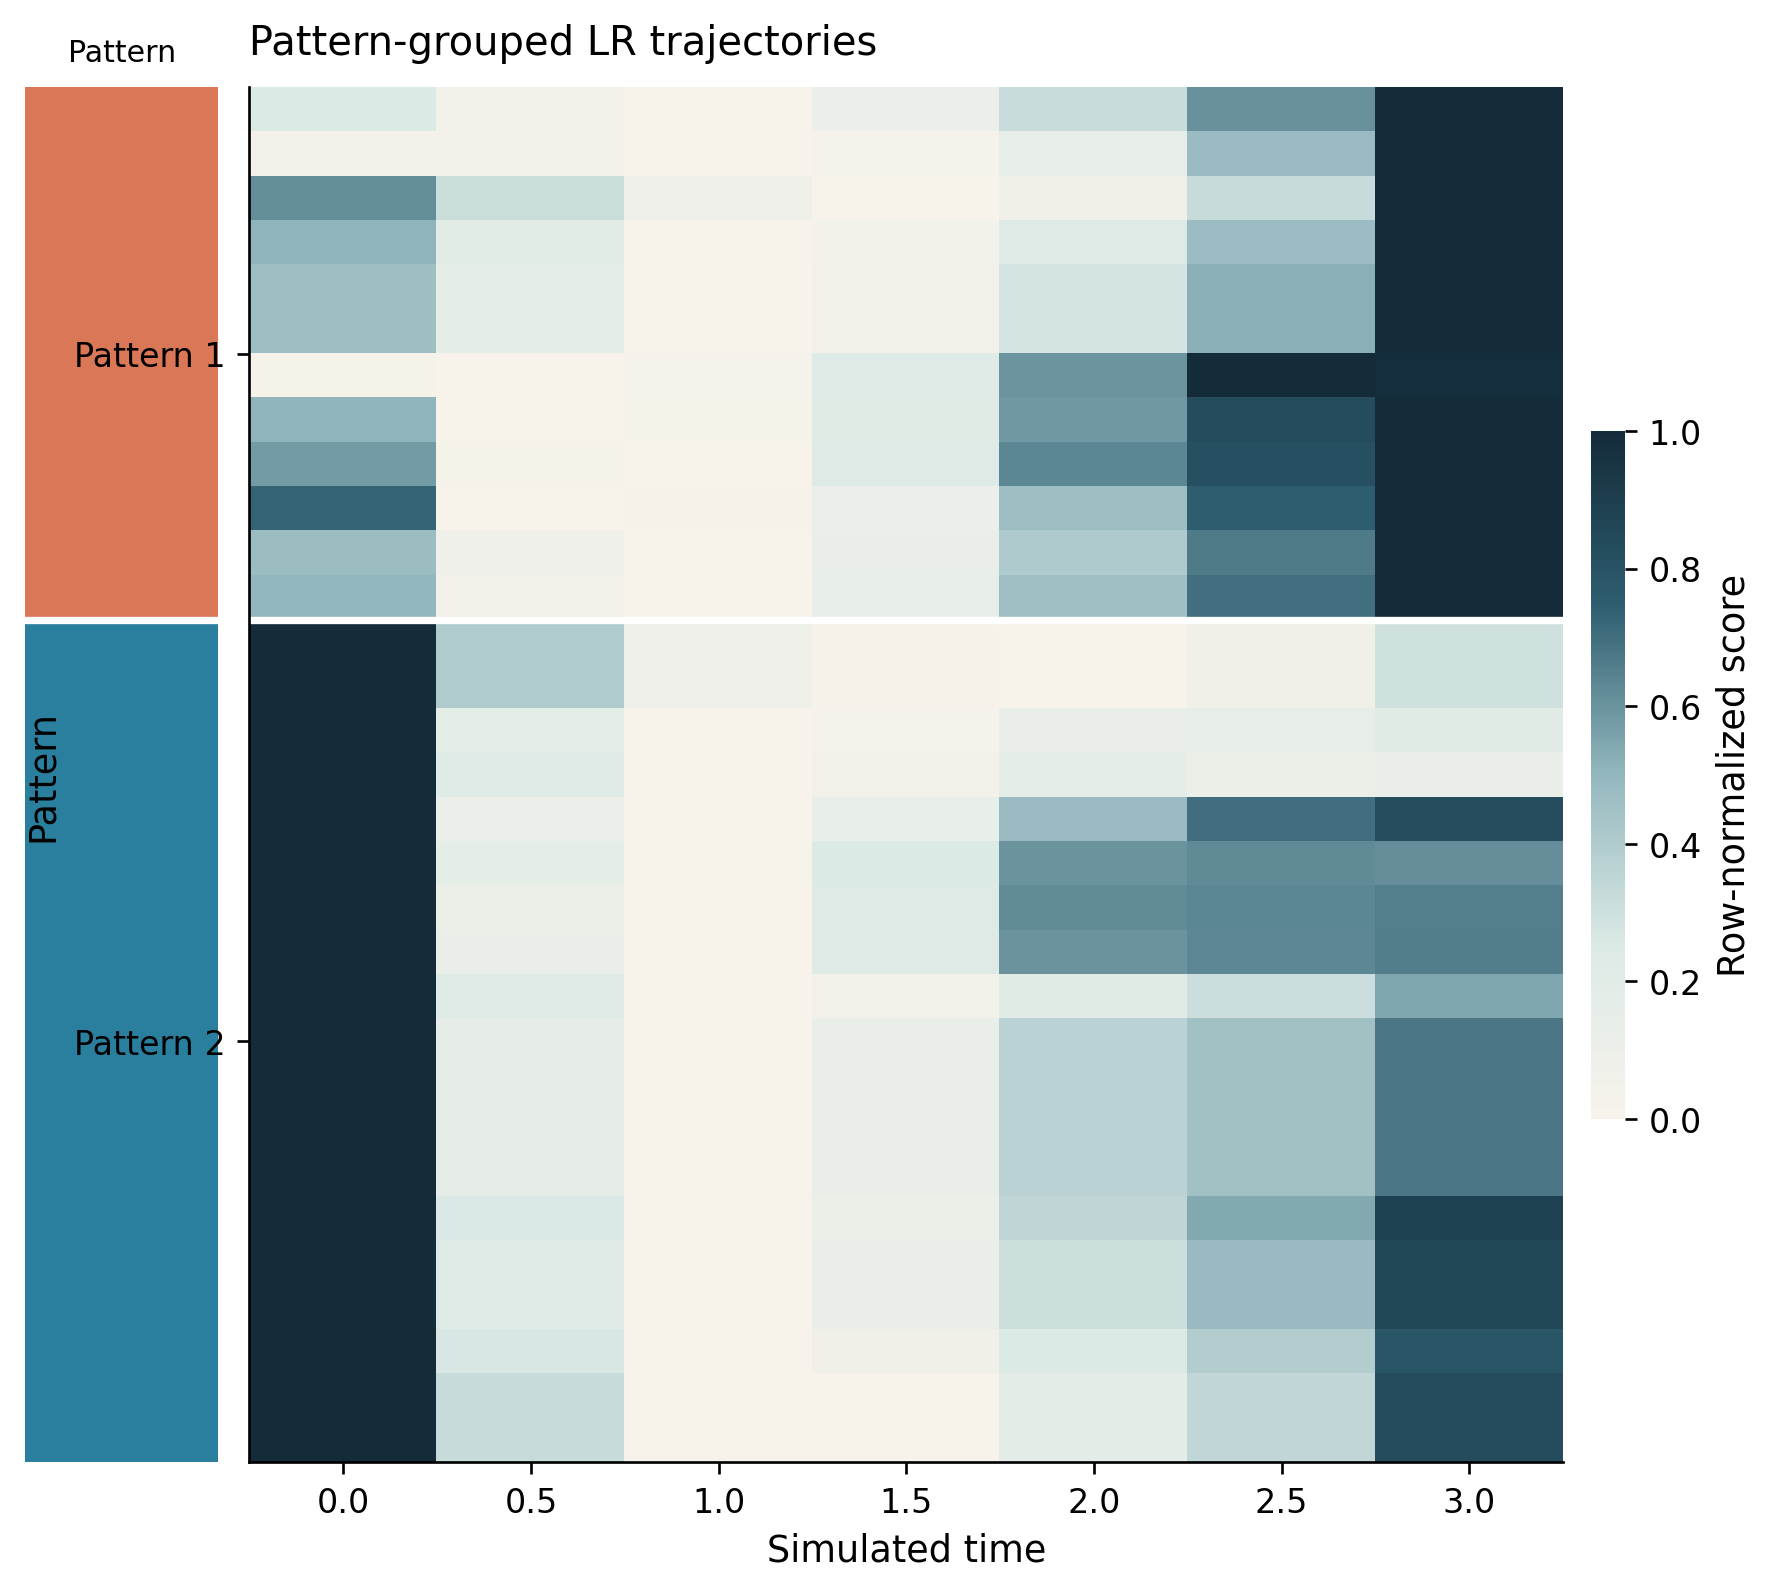

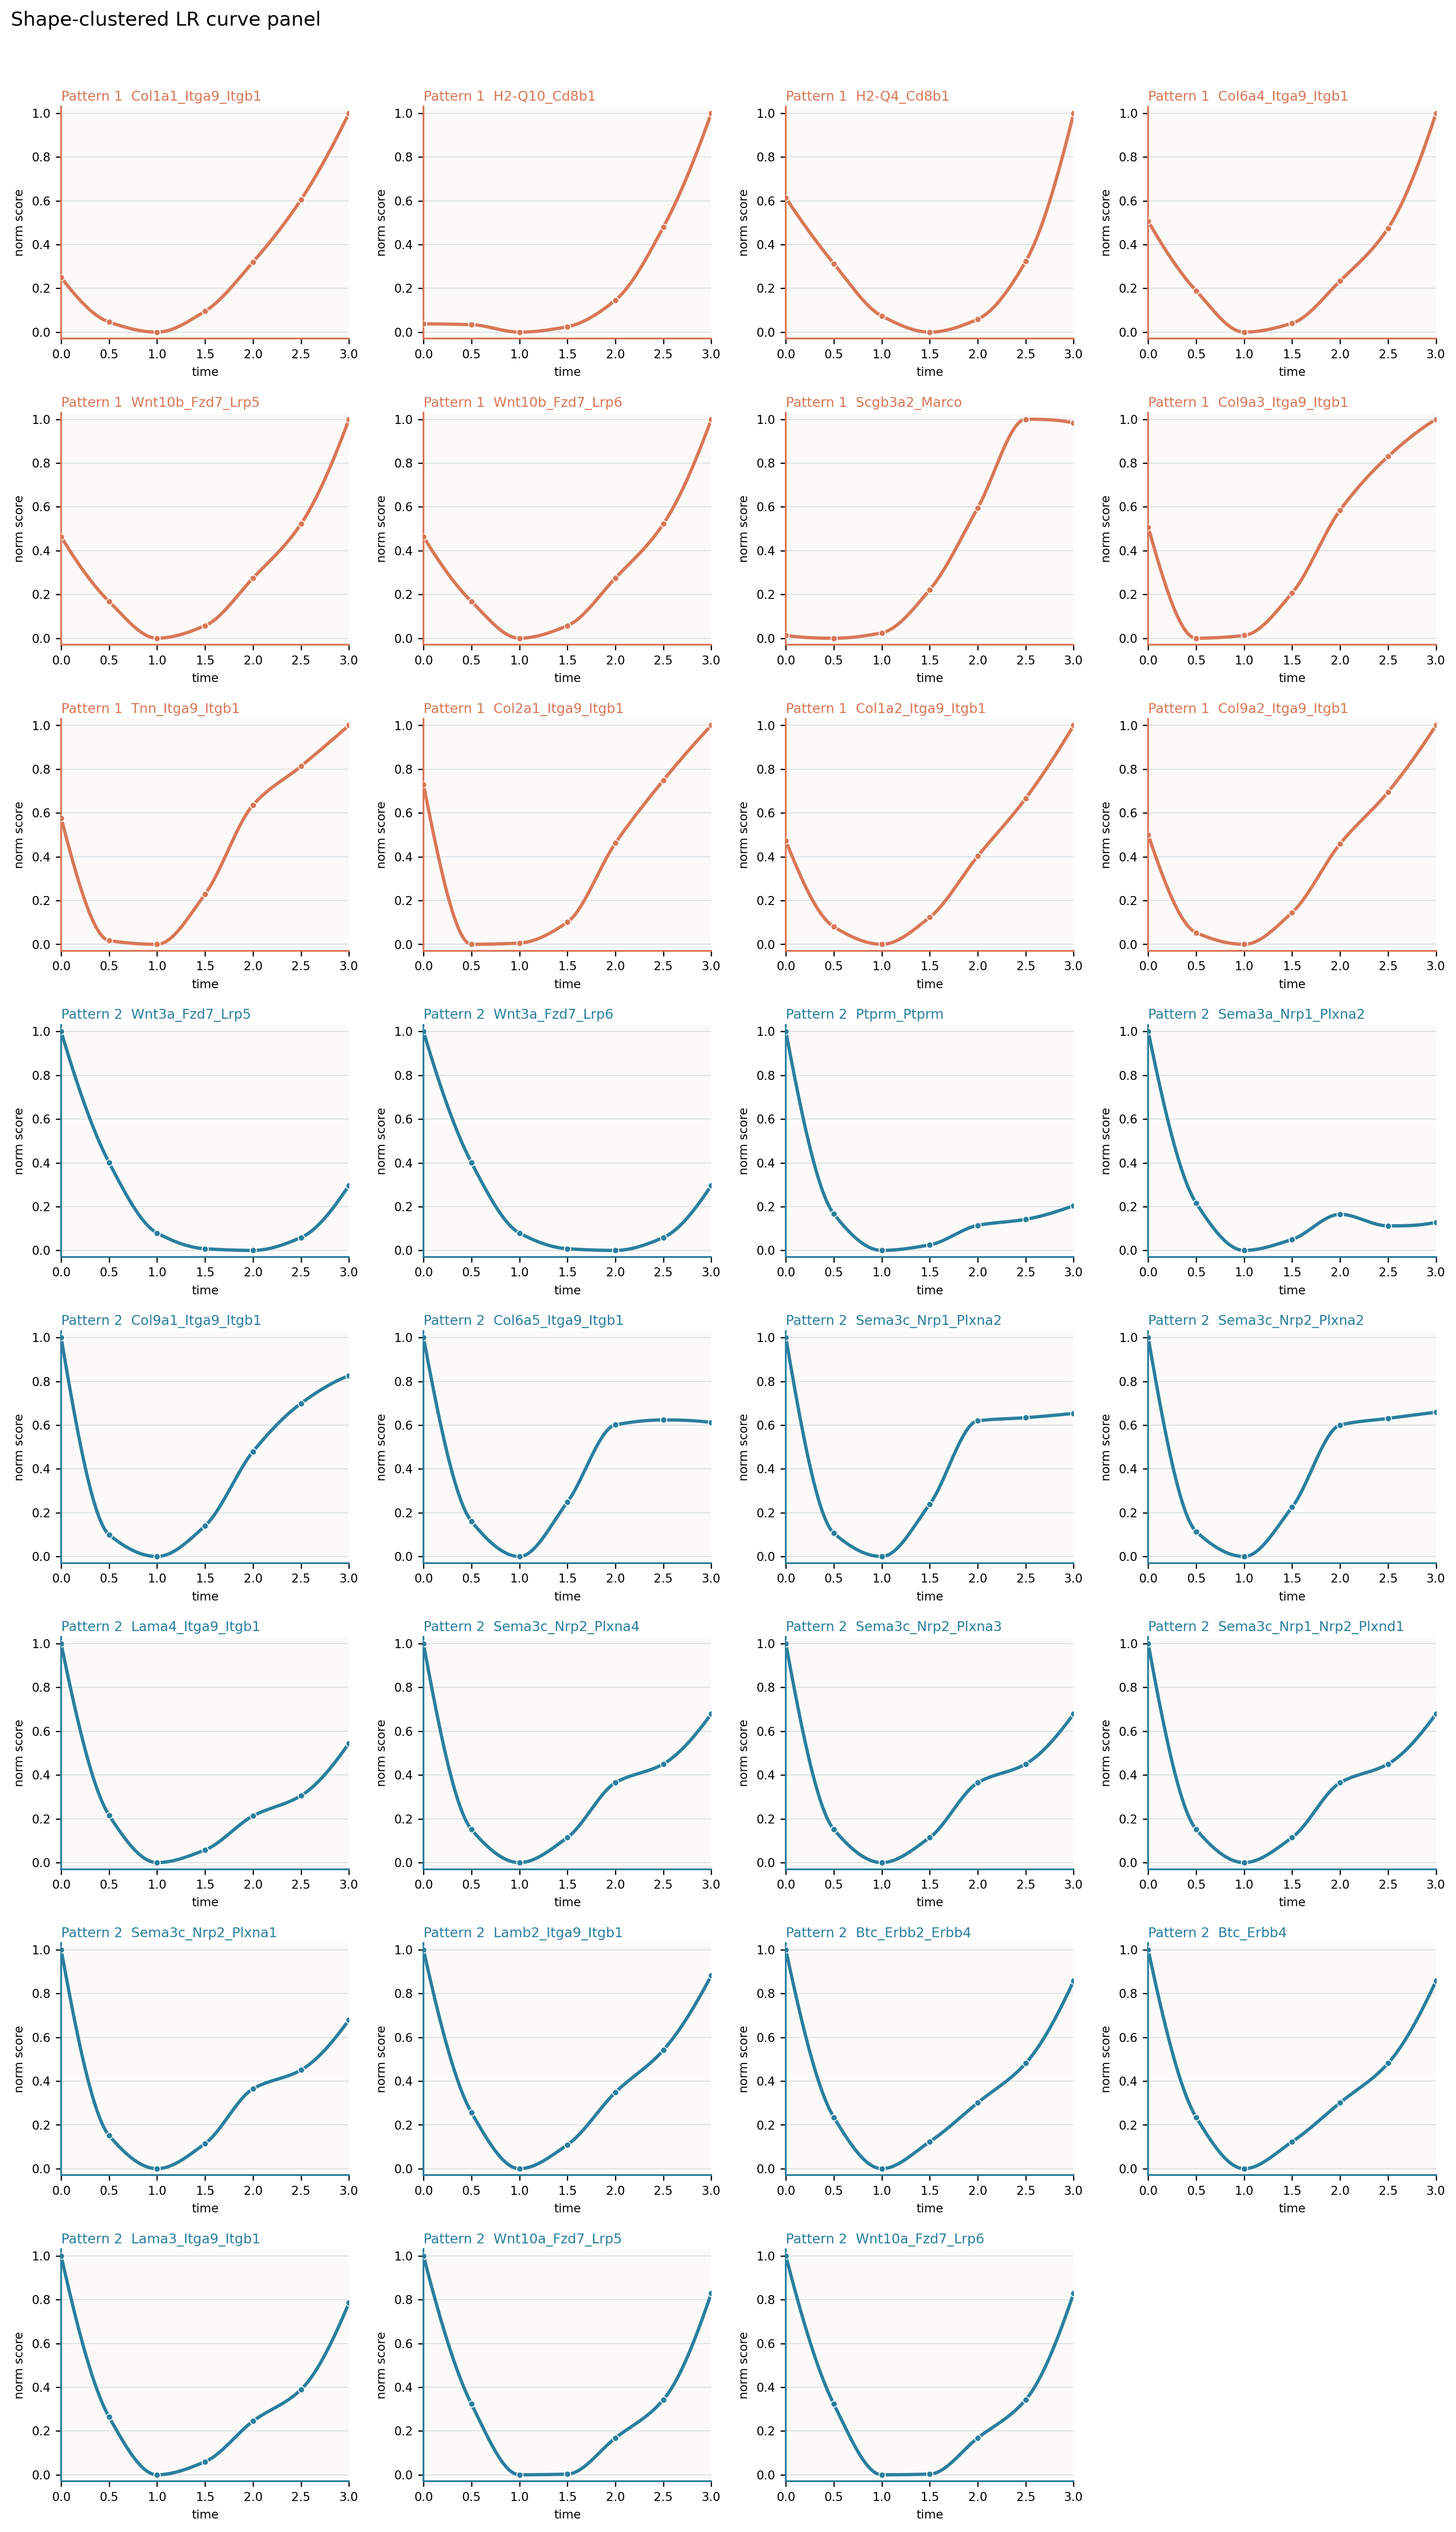

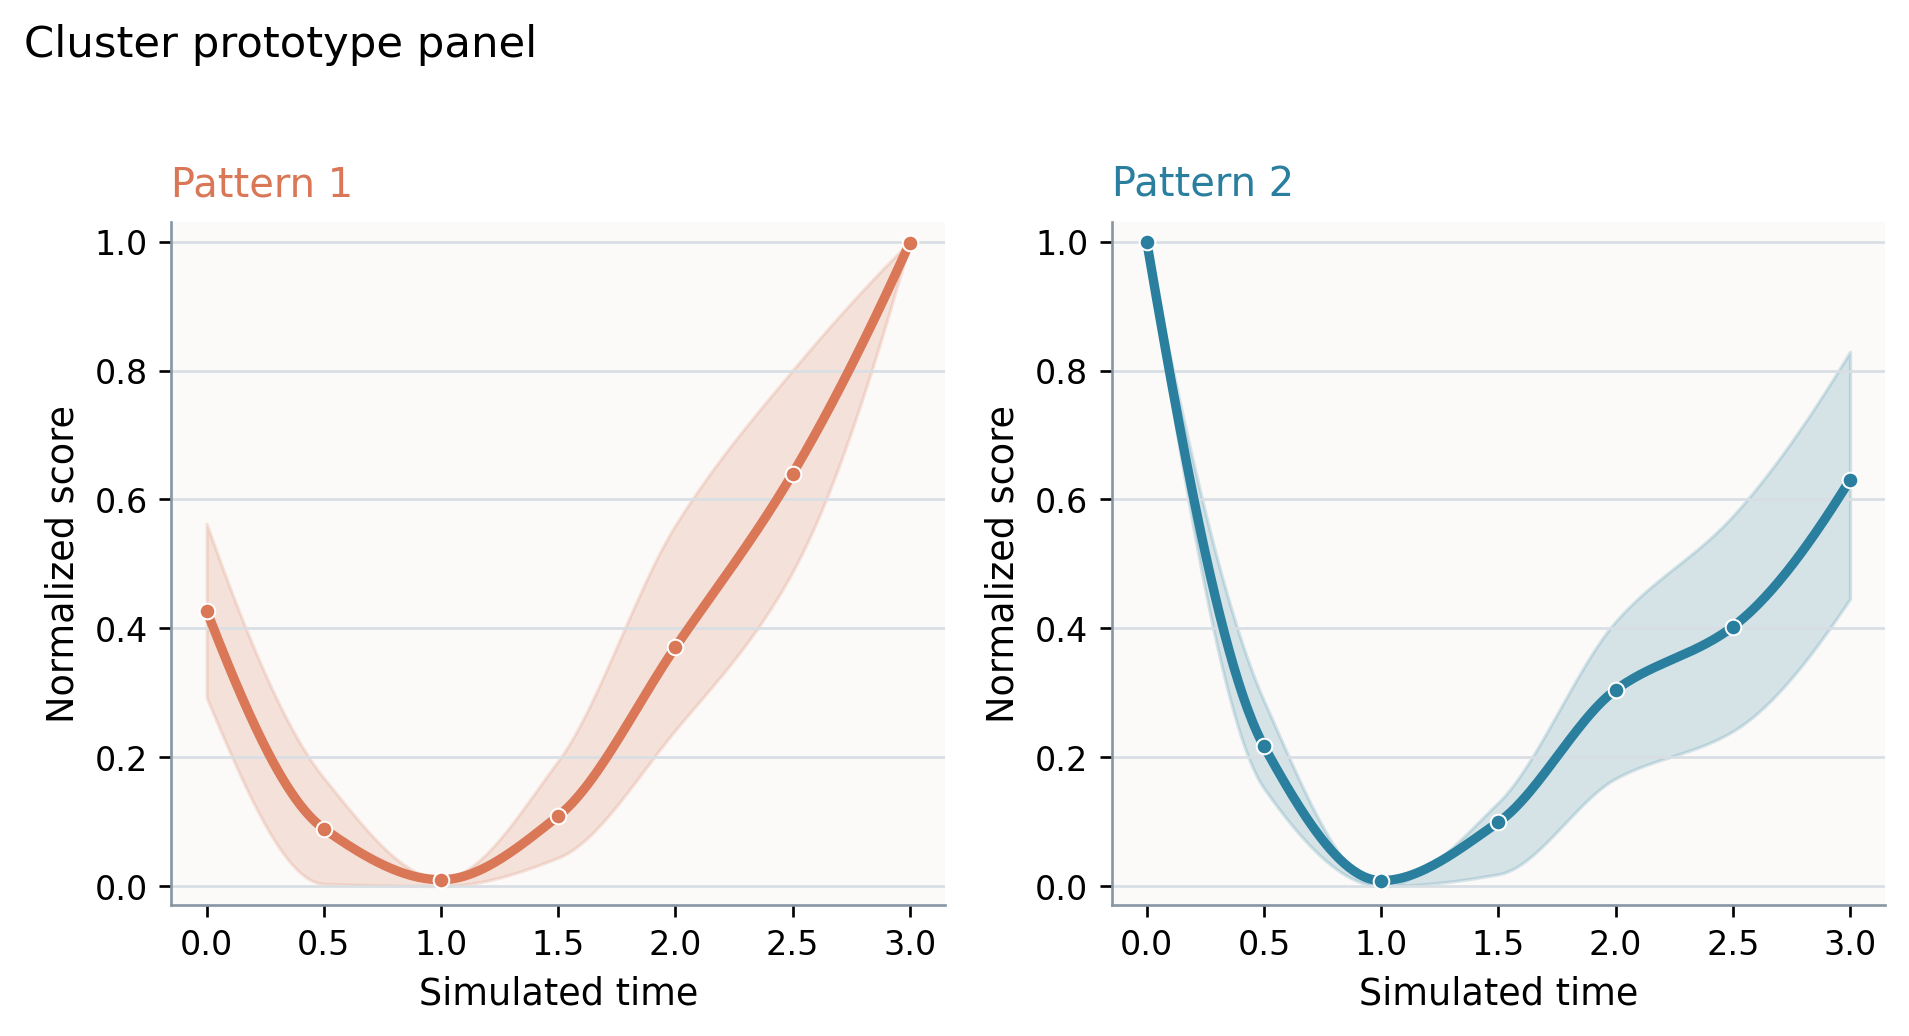

In [7]:
if not pair_df.empty:
    plot_lr_heatmap(
        pair_df,
        pattern_df,
        top_n=min(TOP_N_HEATMAP, pair_df["lr_pair"].nunique()),
        normalize_rows=True,
        out_name="all_lr_heatmap_dense.svg",
    )
    plot_lr_small_multiples(
        pair_df,
        pattern_df,
        top_n=min(TOP_N_SMALL_MULTIPLES, pair_df["lr_pair"].nunique()),
        normalize=True,
        out_name="top_lr_small_multiples_dense.svg",
    )
    plot_cluster_prototypes(
        pair_df,
        pattern_df,
        out_name="cluster_prototype_panel_dense.svg",
    )
    plt.show()
